In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay


nasa_df = pd.read_csv("Nasa_data.csv")
nasa_df.head()

,event_id,title,category,source,date,latitude,longitude,magnitude_value,magnitude_unit,closed
0,EONET_19349,"Holly Springs IU 81-1 83-1 RX Prescribed Fire,...",Wildfires,IRWIN,2026-04-06T09:15:00Z,34.497590,-89.382263,2113.0,acres,NaN
1,EONET_19351,"EASTER PASTURE Wildfire, Hendry, Florida",Wildfires,IRWIN,2026-04-05T22:32:00Z,26.471389,-81.026944,562.0,acres,NaN
2,EONET_19329,Tropical Cyclone Vaianu,Severe Storms,JTWC,2026-04-05T00:00:00Z,-13.800000,171.800000,40.0,kts,NaN
3,EONET_19329,Tropical Cyclone Vaianu,Severe Storms,JTWC,2026-04-05T06:00:00Z,-14.500000,172.300000,55.0,kts,NaN
4,EONET_19329,Tropical Cyclone Vaianu,Severe Storms,JTWC,2026-04-05T12:00:00Z,-14.900000,172.400000,60.0,kts,NaN


In [25]:
nasa_df.isnull().sum()

event_id              0
title                 0
category              0
source                0
date                  0
latitude              0
longitude             0
magnitude_value      19
magnitude_unit       19
closed             1058
dtype: int64

In [26]:
nasa_df.columns

Index(['event_id', 'title', 'category', 'source', 'date', 'latitude',
       'longitude', 'magnitude_value', 'magnitude_unit', 'closed'],
      dtype='object')

In [27]:
def handle_value(nasa_df):
    nasa_df = nasa_df.drop(columns=["closed"], errors="ignore")
    nasa_df = nasa_df.fillna(nasa_df.median(numeric_only=True))
    nasa_df['date'] = pd.to_datetime(nasa_df['date']).dt.date
    return nasa_df

def extract_location(title):
    if isinstance(title, str):
        return title.split(',')[-1].strip()
    return None

def encode_to_numbers(nasa_df):
    category_map = {'Wildfires': 0,'Severe Storms': 1,'Sea and Lake Ice': 2,'Volcanoes': 3}
    nasa_df['category'] = nasa_df['category'].map(category_map)

    source_map = {'IRWIN': 0,'JTWC': 1,'NATICE': 2,'SIVolcano': 3}
    nasa_df['source'] = nasa_df['source'].map(source_map)
    
    location_map = {'Mississippi': 0,'Florida': 1,'Tropical Cyclone Vaianu': 2,'Tropical Cyclone Maila': 3,'California': 4,
    'Wisconsin': 5,'Texas': 6,'Tropical Cyclone Indusa': 7,'Arkansas': 8,'Maryland': 9,'South Carolina': 10,'Oklahoma': 11,'Alabama': 12,
    'Georgia': 13,'North Carolina': 14,'Ohio': 15,'Indiana': 16,'Nebraska': 17,'Missouri': 18,'Idaho': 19,'New Mexico': 20,
    'Washington': 21,'Kansas': 22,'Minnesota': 23,'Louisiana': 24,'Colorado': 25,'Illinois': 26,'Kentucky': 27,'Arizona': 28,
    'Virginia': 29,'Wyoming': 30,'South Dakota': 31,'Utah': 32,'Montana': 33,'Tennessee': 34,'Iceberg D15C': 35,'Nevada': 36,
    'Vanuatu': 37,'Philippines': 38,'Oregon': 39,'Nicaragua': 40,'Peru': 41,'DR Congo': 42,'Colombia': 43,'Papua New Guinea': 44,
    'India': 45,'Ethiopia': 46,'Chile': 47,'Hawaii': 48,'Iceberg C18C': 49,'Japan': 50,'Indonesia': 51,'New Zealand': 52,
    'North Dakota': 53,'Russia': 54,'Alaska': 55}
    nasa_df['location'] = nasa_df['location'].map(location_map)

    le = LabelEncoder()
    nasa_df['magnitude_unit'] = le.fit_transform(nasa_df['magnitude_unit'].astype(str))

    return nasa_df

nasa_df = handle_value(nasa_df)
nasa_df['location'] = nasa_df['title'].apply(extract_location)
nasa_df = encode_to_numbers(nasa_df)

nasa_df.head()

,event_id,title,category,source,date,latitude,longitude,magnitude_value,magnitude_unit,location
0,EONET_19349,"Holly Springs IU 81-1 83-1 RX Prescribed Fire,...",0,0,2026-04-06,34.497590,-89.382263,2113.0,1,0
1,EONET_19351,"EASTER PASTURE Wildfire, Hendry, Florida",0,0,2026-04-05,26.471389,-81.026944,562.0,1,1
2,EONET_19329,Tropical Cyclone Vaianu,1,1,2026-04-05,-13.800000,171.800000,40.0,2,2
3,EONET_19329,Tropical Cyclone Vaianu,1,1,2026-04-05,-14.500000,172.300000,55.0,2,2
4,EONET_19329,Tropical Cyclone Vaianu,1,1,2026-04-05,-14.900000,172.400000,60.0,2,2


In [28]:
clean_df = nasa_df.drop(['event_id', 'title'], axis=1)
clean_df.head()

,category,source,date,latitude,longitude,magnitude_value,magnitude_unit,location
0,0,0,2026-04-06,34.497590,-89.382263,2113.0,1,0
1,0,0,2026-04-05,26.471389,-81.026944,562.0,1,1
2,1,1,2026-04-05,-13.800000,171.800000,40.0,2,2
3,1,1,2026-04-05,-14.500000,172.300000,55.0,2,2
4,1,1,2026-04-05,-14.900000,172.400000,60.0,2,2


In [29]:
clean_df.isna().sum()

category           0
source             0
date               0
latitude           0
longitude          0
magnitude_value    0
magnitude_unit     0
location           0
dtype: int64

In [30]:
clean_df.groupby('magnitude_unit')['magnitude_value'].describe()

,count,mean,std,min,25%,50%,75%,max
magnitude_unit,,,,,,,,
0,14.0,23.007143,9.674841,20.0,20.0,20.0,20.00,56.17
1,977.0,3022.083930,21344.509408,500.0,700.0,1064.0,1922.00,572804.00
2,48.0,76.354167,22.091194,35.0,60.0,77.5,91.25,125.00
3,19.0,1014.000000,0.000000,1014.0,1014.0,1014.0,1014.00,1014.00


In [31]:
clean_df.head()

,category,source,date,latitude,longitude,magnitude_value,magnitude_unit,location
0,0,0,2026-04-06,34.497590,-89.382263,2113.0,1,0
1,0,0,2026-04-05,26.471389,-81.026944,562.0,1,1
2,1,1,2026-04-05,-13.800000,171.800000,40.0,2,2
3,1,1,2026-04-05,-14.500000,172.300000,55.0,2,2
4,1,1,2026-04-05,-14.900000,172.400000,60.0,2,2


# ML Models

## K-Means Clustering

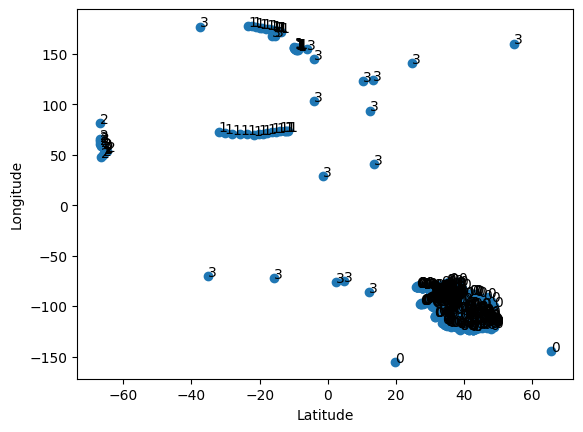

In [32]:
from sklearn.cluster import KMeans

X = clean_df.drop(['date', 'magnitude_unit'], axis=1)
y = clean_df['category']

plt.scatter(X['latitude'], X['longitude'])

for i, txt in enumerate(y):
    plt.annotate(txt, (X['latitude'].iloc[i], X['longitude'].iloc[i]))

plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

In [33]:
from scipy.spatial.distance import cdist
inertias = []
distortions = []

for k in range(1, 10):
    model = KMeans(n_clusters=k).fit(X)

    distance = cdist(X, model.cluster_centers_, 'euclidean')
    distortion = sum(np.min(distance, axis=1)) / X.shape[0]
    distortions.append(distortion)

    inertia = model.inertia_
    inertias.append(inertia)

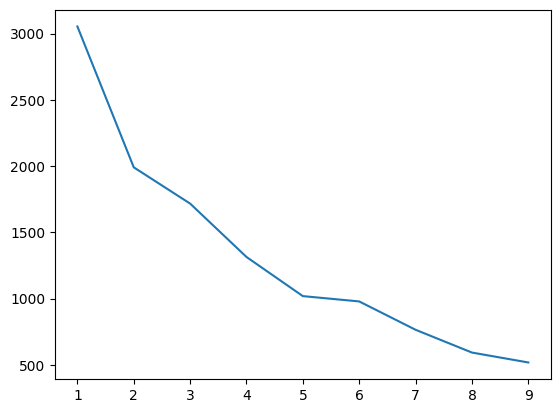

In [34]:
plt.plot(range(1, 10), distortions)

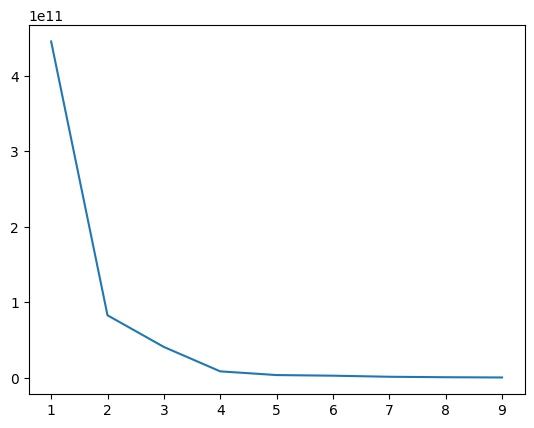

In [35]:
plt.plot(range(1, 10), inertias)

## XG Boost Classifier

In [39]:
median_magnitude = clean_df['magnitude_value'].median()
clean_df['high_severity'] = (clean_df['magnitude_value'] > median_magnitude).astype(int)

print("Median magnitude:", median_magnitude)
print(clean_df['high_severity'].value_counts())


Median magnitude: 1014.0
high_severity
0    541
1    517
Name: count, dtype: int64


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = clean_df.drop(['magnitude_value', 'high_severity', 'date'], axis=1)
y = clean_df['high_severity']  

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=50,
                                                    stratify=y)


In [41]:
from xgboost import XGBClassifier

xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_pred


array([0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,

In [42]:
xgb.score(X_test, y_test)

0.6194968553459119

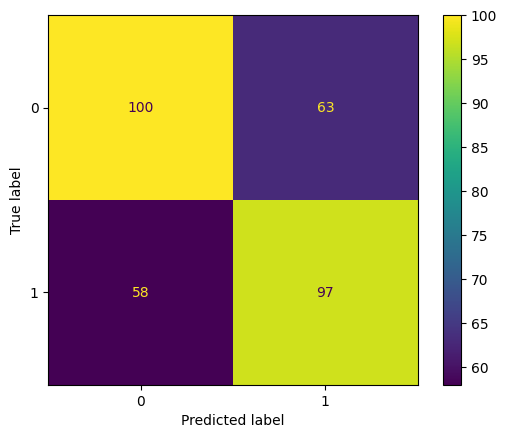

In [43]:
ConfusionMatrixDisplay.from_estimator(xgb, X_test, y_test)

In [44]:
# Recall
97/(97+58)

0.6258064516129033

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)
print(fpr, tpr)

[0.         0.38650307 1.        ] [0.         0.62580645 1.        ]


Text(0.5, 1.0, 'ROC Curve: XGBoost Severity Prediction')

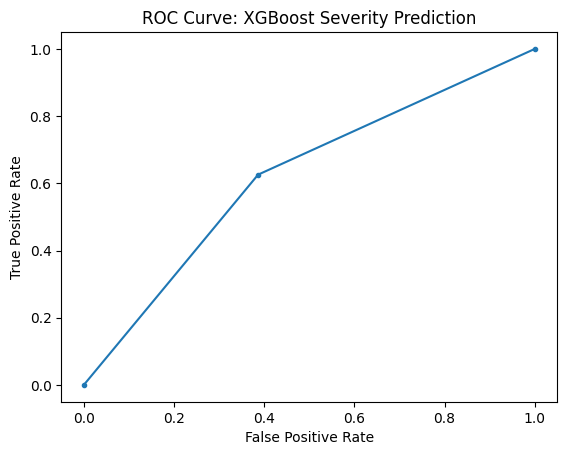

In [46]:
plt.plot(fpr, tpr, marker=".")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: XGBoost Severity Prediction")
